# Optimizing hyperparameters with optuna

### Loading the data from disk (as saved by Prepare-training-data)

In [1]:
import xgboost as xgb
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
from scipy.stats import ks_2samp
import optuna

In [2]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (15,8)
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [3]:
data = np.load("bdt_training_data.npz")
Xtrain_scaled = data['Xtrain_scaled']
ytrain = data['ytrain']
Xvalid_scaled = data['Xvalid_scaled']
yvalid = data['yvalid']
Xtest_scaled = data['Xtest_scaled']
ytest = data['ytest']
train_columns = data['train_columns']
print(f"Ratio bkg/sig:{ np.count_nonzero(ytrain == 0) / np.count_nonzero(ytrain)}")

Ratio bkg/sig:50.82315420188168


In [4]:
Xtrain_scaled.shape

(324983, 23)

In [5]:
Xvalid_scaled.shape

(162408, 23)

In [6]:
Xtest_scaled.shape

(162408, 23)

 # Utility methods

In [7]:
def get_bdt_reponse_similarity(clf, X_train, y_train, X_test, y_test):

    # Getting the BDT response
    train_sig = clf.predict_proba(X_train[y_train==1])[:,1]
    train_bkg = clf.predict_proba(X_train[y_train==0])[:,1]
    test_sig = clf.predict_proba(X_test[y_test==1])[:,1]
    test_bkg = clf.predict_proba(X_test[y_test==0])[:,1]
    
    ks_sig = ks_2samp(train_sig, test_sig, alternative='two-sided')
    ks_bkg = ks_2samp(train_bkg, test_bkg, alternative='two-sided')
    
    return ks_sig, ks_bkg

In [8]:
def train_model(Xtrain_scaled, ytrain, Xvalid_scaled, yvalid, Xtest_scaled, ytest, n_estimators=200, eta=0.07, max_depth=3):

    # Used for the scale_pos_weight in the model
    ratio = np.count_nonzero(ytrain == 0) / np.count_nonzero(ytrain)

    
    model = xgb.XGBClassifier( eval_metric='logloss', 
                              n_estimators=n_estimators, 
                              eta=eta, 
                              #gamma=0.10,
                              #reg_lambda=4.34,
                              scale_pos_weight=ratio, 
                              max_depth=max_depth, 
                              random_state=42, tree_method="gpu_hist", verbosity=1, seed=42)

    
    # Now train
    evalset = [(Xtrain_scaled, ytrain), (Xvalid_scaled, yvalid)]
    res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset, verbose=False)
    
    # Predict on test set 
    yscore = model.predict_proba(Xtest_scaled)
    fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
    roc_auc = auc(fpr, tpr)
    
    # Measure overtraining
    kss, ksb = get_bdt_reponse_similarity(model, Xtrain_scaled, ytrain, Xtest_scaled, ytest)
    return roc_auc, kss, ksb

In [9]:
def cross_train_model(Xtrain_scaled, ytrain, Xvalid_scaled, yvalid, n_estimators=200, eta=0.03, max_depth=4):

    # Used for the scale_pos_weight in the model
    ratio = np.count_nonzero(ytrain == 0) / np.count_nonzero(ytrain)

    
    model = xgb.XGBClassifier( eval_metric='logloss', 
                              n_estimators=n_estimators, 
                              eta=eta, 
                              #gamma=0.10,
                              #reg_lambda=4.34,
                              scale_pos_weight=ratio, 
                              max_depth=max_depth, 
                              random_state=42, tree_method="gpu_hist", verbosity=1, seed=42)

    
    cvs = cross_validate(model, Xtrain_scaled, ytrain, cv=5, scoring='roc_auc', return_estimator=True)
    all_auc = []
    all_kss = []
    all_ksb = []
    
    for i, model in enumerate(cvs['estimator']):
        # Predict on test set 
        yscore = model.predict_proba(Xvalid_scaled)
        fpr, tpr, _ = roc_curve(yvalid, yscore[:,1])
        roc_auc = auc(fpr, tpr)        
            
        # Measure overtraining
        kss, ksb = get_bdt_reponse_similarity(model, Xtrain_scaled, ytrain, Xvalid_scaled, yvalid)
        all_auc.append(roc_auc)
        all_kss.append(kss)
        all_ksb.append(ksb)
    return all_auc, all_kss, all_ksb


In [19]:
def objective(trial):
    ratio = np.count_nonzero(ytrain == 0) / np.count_nonzero(ytrain)
    model = xgb.XGBClassifier(eval_metric='logloss', 
                              n_estimators=trial.suggest_int("n_estimators", 100, 201, step=50), 
                              eta=trial.suggest_float("eta", 0.01, 0.10, step=0.01), # 0.03, 
                              scale_pos_weight=ratio, 
                              max_depth=trial.suggest_int("max_depth", 3, 6), #4
                              gamma=trial.suggest_float("gamma", 0, 0.2),
                              #reg_lambda=trial.suggest_float("lambda", 1.0, 10.0),
                              random_state=42, 
                              tree_method="gpu_hist",
                              verbosity=0)
    evalset = [(Xtrain_scaled, ytrain), (Xvalid_scaled, yvalid)]
    res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset, verbose=False)
    yscore = model.predict_proba(Xvalid_scaled)
    fpr, tpr, _ = roc_curve(yvalid, yscore[:,1])
    roc_auc = auc(fpr, tpr)
    ks, kb = get_bdt_reponse_similarity(model, Xtrain_scaled, ytrain, Xtest_scaled, ytest)
    return (1 - roc_auc) * ks.statistic

In [20]:
%time

study_name = "optuna-bdt-opt"
study = optuna.create_study(direction="minimize", study_name=study_name, storage="sqlite:///{}.db".format(study_name), load_if_exists=True)
study.optimize(objective, n_trials=100)
print(study.best_trial)




[I 2023-09-11 17:56:34,749] Using an existing study with name 'optuna-bdt-opt' instead of creating a new one.


CPU times: user 6 µs, sys: 0 ns, total: 6 µs
Wall time: 11.9 µs


/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:56:35,658] Trial 100 finished with value: 0.004178938296410241 and parameters: {'n_estimators': 100, 'eta': 0.02, 'max_depth': 3, 'gamma': 0.07575881215435701}. Best is trial 17 with value: 0.003943682944854468.
/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:56:36,497] Trial 101 finished with value: 0.004178938296410241 and parameters: {'n_estimators': 100, 'eta': 0.02, 'max_depth': 3, 'gamma': 0.0820880736824258}. Best is trial 17 with value: 0.003943682944854468.
/opt/miniconda3/envs/lb-conda-g

/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:56:52,346] Trial 117 finished with value: 0.003762552131106066 and parameters: {'n_estimators': 150, 'eta': 0.04, 'max_depth': 3, 'gamma': 0.12111735655837733}. Best is trial 111 with value: 0.003762552131106066.
/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:56:53,308] Trial 118 finished with value: 0.003762552131106066 and parameters: {'n_estimators': 150, 'eta': 0.04, 'max_depth': 3, 'gamma': 0.1266224889654034}. Best is trial 111 with value: 0.003762552131106066.
/opt/miniconda3/envs/lb-conda

/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:57:09,281] Trial 134 finished with value: 0.003762552131106066 and parameters: {'n_estimators': 150, 'eta': 0.04, 'max_depth': 3, 'gamma': 0.11717592840644725}. Best is trial 111 with value: 0.003762552131106066.
/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:57:10,257] Trial 135 finished with value: 0.003762552131106066 and parameters: {'n_estimators': 150, 'eta': 0.04, 'max_depth': 3, 'gamma': 0.1222922681964445}. Best is trial 111 with value: 0.003762552131106066.
/opt/miniconda3/envs/lb-conda

/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:57:26,343] Trial 151 finished with value: 0.003762552131106066 and parameters: {'n_estimators': 150, 'eta': 0.04, 'max_depth': 3, 'gamma': 0.1201764993690229}. Best is trial 111 with value: 0.003762552131106066.
/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:57:27,321] Trial 152 finished with value: 0.003762552131106066 and parameters: {'n_estimators': 150, 'eta': 0.04, 'max_depth': 3, 'gamma': 0.1213993272392934}. Best is trial 111 with value: 0.003762552131106066.
/opt/miniconda3/envs/lb-conda-

/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:57:43,133] Trial 168 finished with value: 0.003762552131106066 and parameters: {'n_estimators': 150, 'eta': 0.04, 'max_depth': 3, 'gamma': 0.12045628471014846}. Best is trial 111 with value: 0.003762552131106066.
/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:57:44,103] Trial 169 finished with value: 0.003960236988515586 and parameters: {'n_estimators': 150, 'eta': 0.05, 'max_depth': 3, 'gamma': 0.11396867348836037}. Best is trial 111 with value: 0.003762552131106066.
/opt/miniconda3/envs/lb-cond

/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:57:59,866] Trial 185 finished with value: 0.003762552131106066 and parameters: {'n_estimators': 150, 'eta': 0.04, 'max_depth': 3, 'gamma': 0.12722453005318227}. Best is trial 111 with value: 0.003762552131106066.
/opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/optuna/distributions.py:700: UserWarning: The distribution is specified by [100, 201] and step=50, but the range is not divisible by `step`. It will be replaced by [100, 200].
  warnings.warn(
[I 2023-09-11 17:58:00,845] Trial 186 finished with value: 0.003960236988515586 and parameters: {'n_estimators': 150, 'eta': 0.05, 'max_depth': 3, 'gamma': 0.11999771471192804}. Best is trial 111 with value: 0.003762552131106066.
/opt/miniconda3/envs/lb-cond

FrozenTrial(number=111, state=TrialState.COMPLETE, values=[0.003762552131106066], datetime_start=datetime.datetime(2023, 9, 11, 17, 56, 45, 575087), datetime_complete=datetime.datetime(2023, 9, 11, 17, 56, 46, 516928), params={'n_estimators': 150, 'eta': 0.04, 'max_depth': 3, 'gamma': 0.11136310347001808}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=200, log=False, low=100, step=50), 'eta': FloatDistribution(high=0.1, log=False, low=0.01, step=0.01), 'max_depth': IntDistribution(high=6, log=False, low=3, step=1), 'gamma': FloatDistribution(high=0.2, log=False, low=0.0, step=None)}, trial_id=112, value=None)


In [67]:
study.best_trial.params

{'n_estimators': 150,
 'eta': 0.04,
 'max_depth': 3,
 'gamma': 0.11136310347001808}

In [68]:
params = study.best_trial.params
#params = {'n_estimators': 100, 'eta': 0.08, 'max_depth': 3}
ratio = np.count_nonzero(ytrain == 0) / np.count_nonzero(ytrain)
model = xgb.XGBClassifier( eval_metric='logloss', 
                          #n_estimators=120, 
                          #eta=0.10, 
                          #max_depth=3, 
                          scale_pos_weight=ratio, 
                          random_state=42, tree_method="hist", 
                          verbosity=1, **params)

In [69]:
%%time
evalset = [(Xtrain_scaled, ytrain), (Xvalid_scaled, yvalid)]
res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset, verbose=True)

[0]	validation_0-logloss:0.68377	validation_1-logloss:0.68370
[1]	validation_0-logloss:0.67520	validation_1-logloss:0.67505
[2]	validation_0-logloss:0.66733	validation_1-logloss:0.66712
[3]	validation_0-logloss:0.65992	validation_1-logloss:0.65966
[4]	validation_0-logloss:0.65300	validation_1-logloss:0.65267
[5]	validation_0-logloss:0.64643	validation_1-logloss:0.64612
[6]	validation_0-logloss:0.64021	validation_1-logloss:0.63988
[7]	validation_0-logloss:0.63432	validation_1-logloss:0.63394
[8]	validation_0-logloss:0.62883	validation_1-logloss:0.62846
[9]	validation_0-logloss:0.62350	validation_1-logloss:0.62306
[10]	validation_0-logloss:0.61807	validation_1-logloss:0.61760
[11]	validation_0-logloss:0.61319	validation_1-logloss:0.61268
[12]	validation_0-logloss:0.60846	validation_1-logloss:0.60796
[13]	validation_0-logloss:0.60371	validation_1-logloss:0.60319
[14]	validation_0-logloss:0.59956	validation_1-logloss:0.59897
[15]	validation_0-logloss:0.59522	validation_1-logloss:0.59465
[1

[130]	validation_0-logloss:0.44810	validation_1-logloss:0.44691
[131]	validation_0-logloss:0.44768	validation_1-logloss:0.44650
[132]	validation_0-logloss:0.44727	validation_1-logloss:0.44609
[133]	validation_0-logloss:0.44693	validation_1-logloss:0.44574
[134]	validation_0-logloss:0.44649	validation_1-logloss:0.44529
[135]	validation_0-logloss:0.44591	validation_1-logloss:0.44472
[136]	validation_0-logloss:0.44556	validation_1-logloss:0.44438
[137]	validation_0-logloss:0.44529	validation_1-logloss:0.44411
[138]	validation_0-logloss:0.44484	validation_1-logloss:0.44363
[139]	validation_0-logloss:0.44421	validation_1-logloss:0.44303
[140]	validation_0-logloss:0.44383	validation_1-logloss:0.44265
[141]	validation_0-logloss:0.44333	validation_1-logloss:0.44216
[142]	validation_0-logloss:0.44295	validation_1-logloss:0.44178
[143]	validation_0-logloss:0.44261	validation_1-logloss:0.44143
[144]	validation_0-logloss:0.44231	validation_1-logloss:0.44114
[145]	validation_0-logloss:0.44198	valid

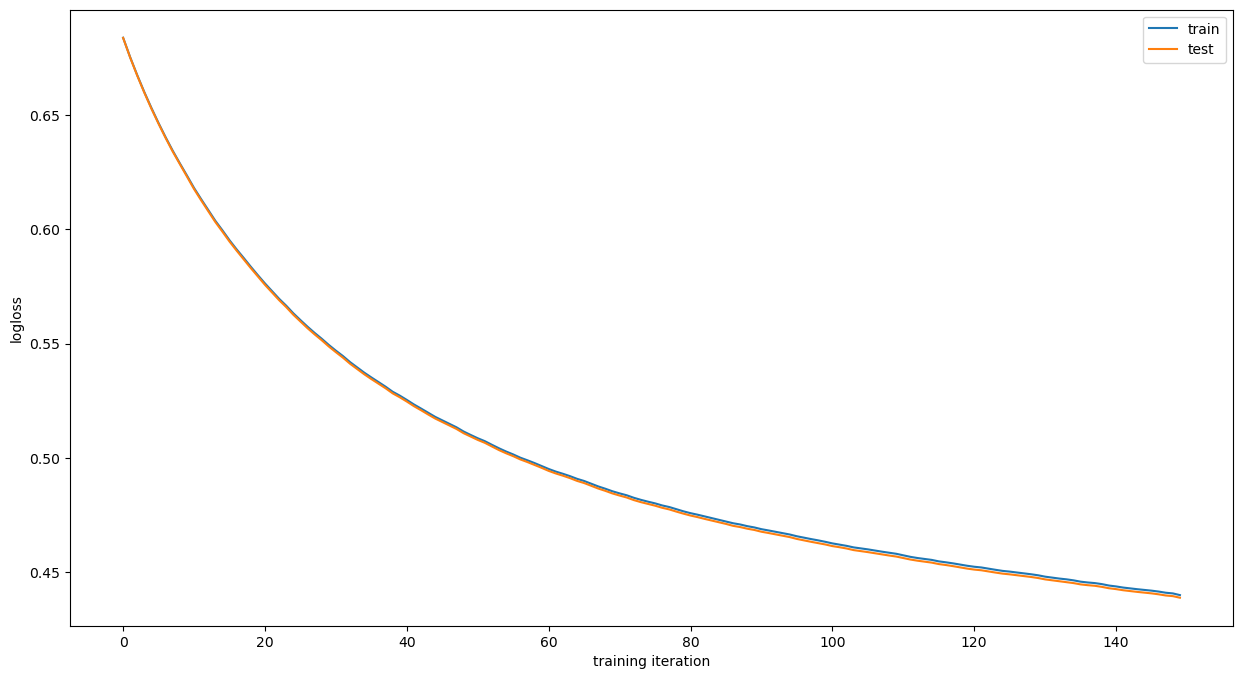

In [62]:
results = model.evals_result()
# plot learning curves
plt.plot(results['validation_0']['logloss'], label='train')
plt.plot(results['validation_1']['logloss'], label='test')
# show the legend
plt.legend()
# show the plotabs
plt.ylabel("logloss")
plt.xlabel("training iteration")
plt.show()

0.8778216821401145


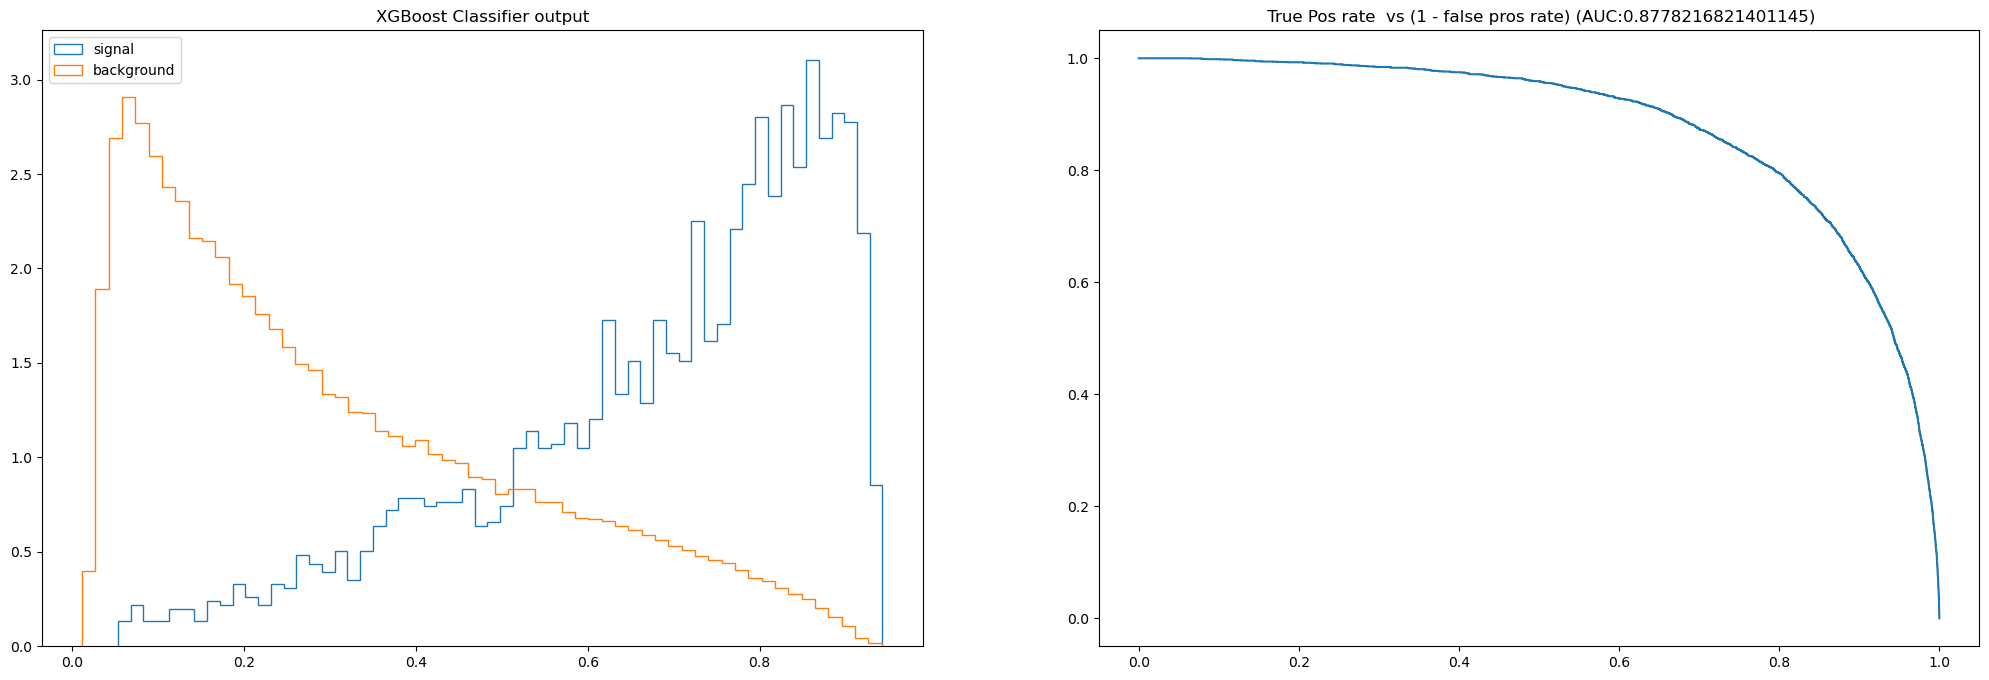

In [70]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = model.predict_proba(Xtest_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"XGBoost Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal', density=True);
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background', density=True);
ax1.legend();

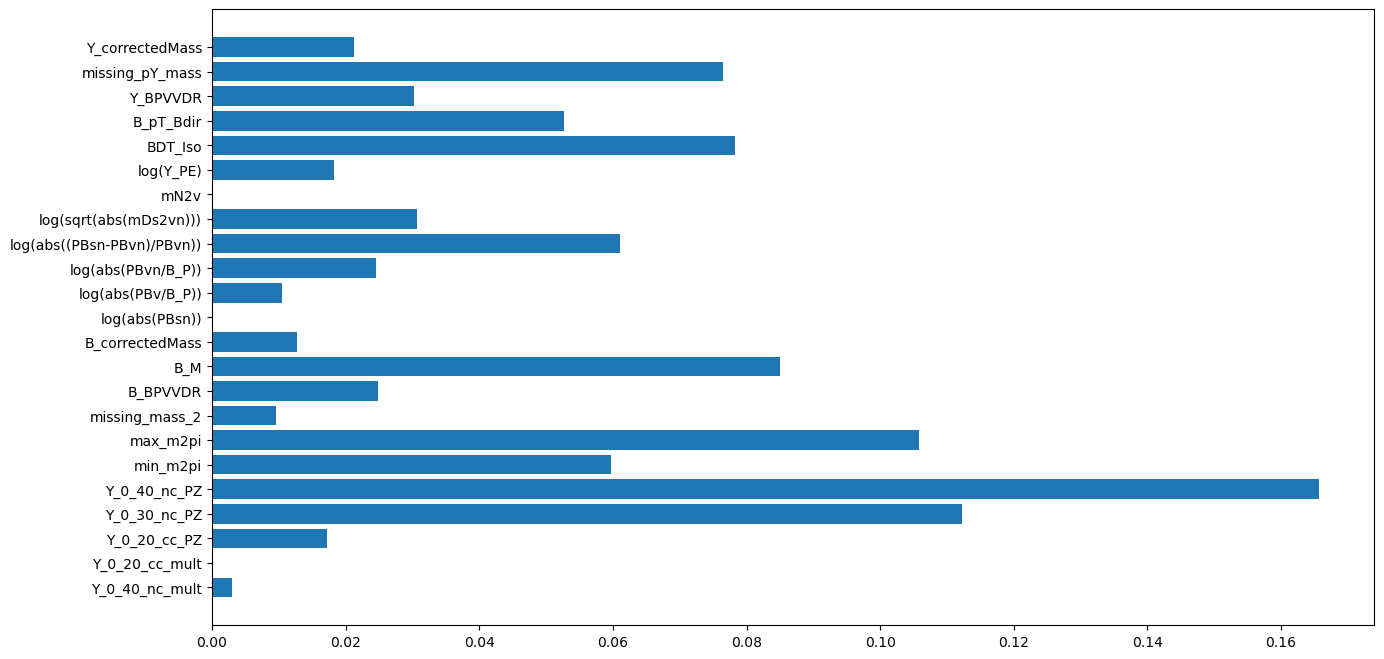

In [71]:
plt.barh(train_columns, model.feature_importances_);

4


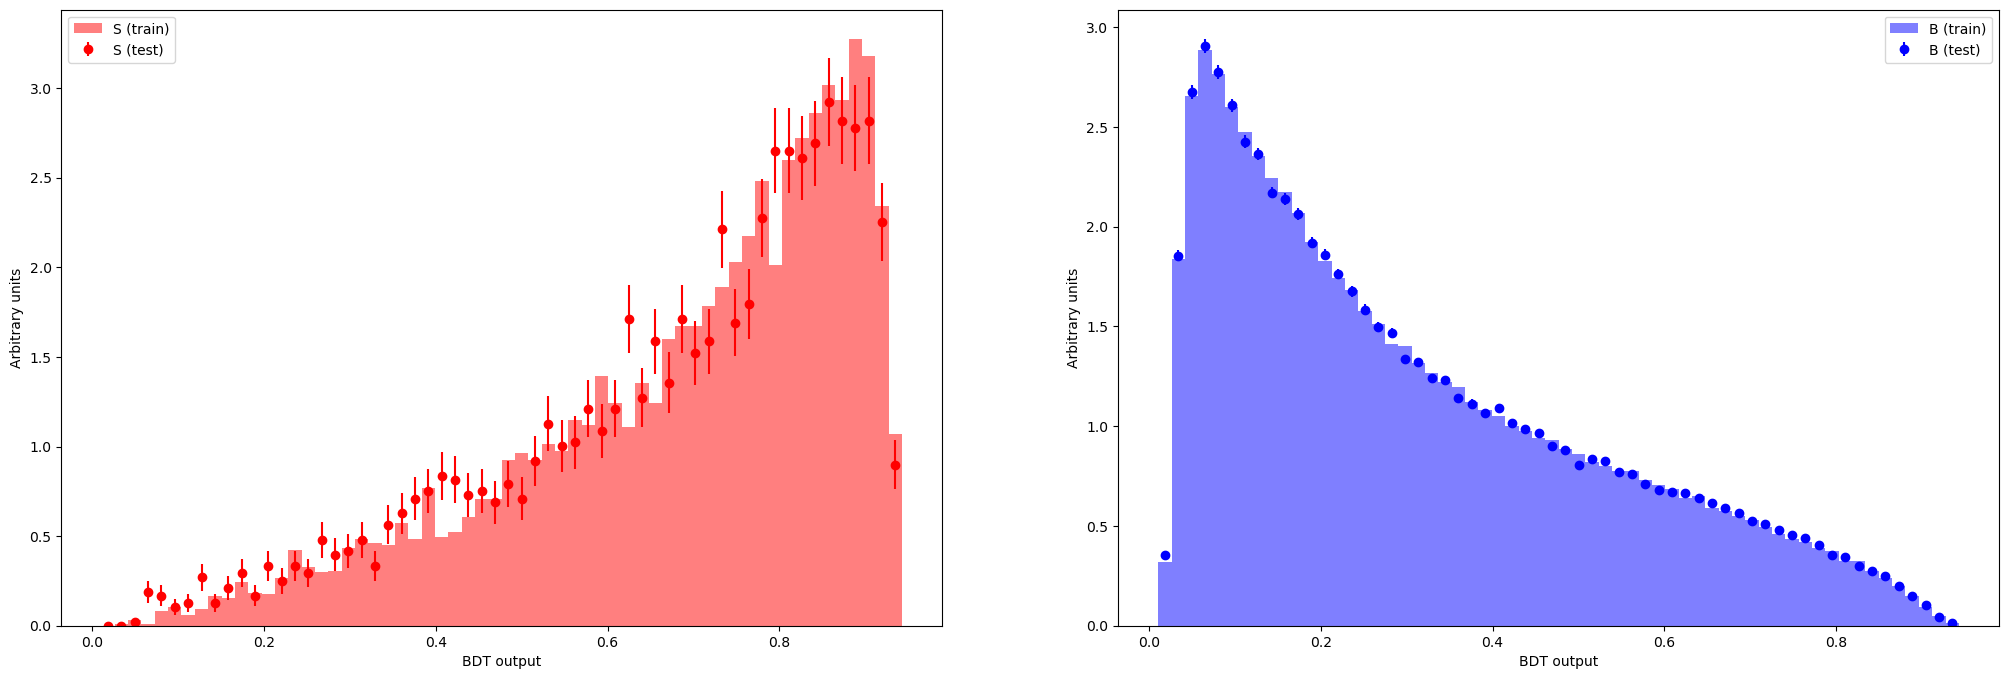

In [72]:
def compare_train_test(clf, X_train, y_train, X_test, y_test, bins=60):
    ''' Taken from Tim Head's recipe: https://betatim.github.io/posts/sklearn-for-TMVA-users/ '''
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))
    decisions = []
    for X,y in ((X_train, y_train), (X_test, y_test)):
        d1 = clf.predict_proba(X[y==1])[:,1]
        d2 = clf.predict_proba(X[y==0])[:,1]
        decisions += [d1, d2]
        
    print(len(decisions))
        
    low = min(np.min(d) for d in decisions)
    high = max(np.max(d) for d in decisions)
    low_high = (low,high)
    
    ax1.hist(decisions[0],
             color='r', alpha=0.5, range=low_high, bins=bins,
             histtype='stepfilled', density=True,
             label='S (train)')
    ax2.hist(decisions[1],
             color='b', alpha=0.5, range=low_high, bins=bins,
             histtype='stepfilled', density=True,
             label='B (train)')

    
    hist, bins = np.histogram(decisions[2],
                              bins=bins, range=low_high, density=True)
    scale = len(decisions[2]) / sum(hist)
    err = np.sqrt(hist * scale) / scale
    
    width = (bins[1] - bins[0])
    center = (bins[:-1] + bins[1:]) / 2
    ax1.errorbar(center, hist, yerr=err, fmt='o', c='r', label='S (test)')
    
    hist, bins = np.histogram(decisions[3],
                              bins=bins, range=low_high, density=True)

    scale = len(decisions[3]) / sum(hist)
    
    err = np.sqrt(hist * scale) / scale

    ax2.errorbar(center, hist, yerr=err, fmt='o', c='b', label='B (test)')

    ax1.set_xlabel("BDT output")
    ax1.set_ylabel("Arbitrary units")
    ax1.legend(loc='best')

    ax2.set_xlabel("BDT output")
    ax2.set_ylabel("Arbitrary units")
    ax2.legend(loc='best')

    
compare_train_test(model, Xtrain_scaled, ytrain, Xtest_scaled, ytest)
